In [249]:
# Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [250]:
# Carga desde un archivo .csv sin indice
bp = pd.read_csv('Bitacora_piso.csv') 

In [274]:
# Verificamos información del DataFrame
bp.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Fecha                                       207 non-null    str  
 1   Nombre Cliente                              207 non-null    str  
 2   Asesor                                      207 non-null    str  
 3   Esatus Lead                                 207 non-null    str  
 4   PDM                                         207 non-null    bool 
 5   SDC                                         207 non-null    bool 
 6   Venta                                       207 non-null    bool 
 7   Inter Gerente                               207 non-null    bool 
 8   ¿Por que no hubo prueba de manejo?          207 non-null    str  
 9   ¿Por que no hubo Solicitud de credito?      207 non-null    str  
 10  ¿Por que no hubo intervencion del Gerente?  207 n

In [252]:
# LIMPIAR NOMBRES COLUMNAS
bp.columns = bp.columns.str.strip()

In [253]:
# CAMBIAR TIPOS DE DATOS
bp['SDC'] = bp['SDC'].astype(bool)
bp['Venta'] = bp['Venta'].astype(bool)
bp['Inter Gerente'] = bp['Inter Gerente'].astype(bool)


In [254]:
# ELIMINAR COLUMNAS
bp = bp.drop(columns=['Telefono', 'Estatus de SDC','Temperatura', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29'])

In [255]:
# ELIMINAR FILAS VACÍAS
bp = bp.drop(bp.index[207:236])

In [256]:
# TRATAR NULOS
bp.isnull().sum()

Fecha                                          11
Nombre Cliente                                 11
Asesor                                         12
Esatus Lead                                    11
PDM                                             0
SDC                                             0
Venta                                           0
Inter Gerente                                   0
¿Por que no hubo prueba de manejo?            191
¿Por que no hubo Solicitud de credito?        193
¿Por que no hubo intervencion del Gerente?    196
¿Por que no hubo proceso wow?                 195
¿Por que no se ha formalizado la compra?      196
5 porques clientes de piso                    199
Comentarios                                   185
dtype: int64

In [257]:
# REEMPLAZAR NULOS POR STRING
bp['Fecha'] = bp['Fecha'].fillna('Sin fecha')
bp['Nombre Cliente'] = bp['Nombre Cliente'].fillna('Sin datos')
bp['Asesor'] = bp['Asesor'].fillna('Sin datos')
bp['Esatus Lead'] = bp['Esatus Lead'].fillna('Sin datos')
bp['¿Por que no hubo prueba de manejo?'] = bp['¿Por que no hubo prueba de manejo?'].fillna('Sin comentarios')
bp['¿Por que no hubo Solicitud de credito?'] = bp['¿Por que no hubo Solicitud de credito?'].fillna('Sin comentarios')
bp['¿Por que no hubo intervencion del Gerente?'] = bp['¿Por que no hubo intervencion del Gerente?'].fillna('Sin comentarios')
bp['¿Por que no hubo proceso wow?'] = bp['¿Por que no hubo proceso wow?'].fillna('Sin comentarios')
bp['¿Por que no se ha formalizado la compra?'] = bp['¿Por que no se ha formalizado la compra?'].fillna('Sin comentarios')
bp['5 porques clientes de piso'] = bp['5 porques clientes de piso'].fillna('Sin razones')
bp['Comentarios'] = bp['Comentarios'].fillna('Sin comentarios')

In [258]:
# Imprimo los primeros 5 registro del dataframe
bp.head(5)

,Fecha,Nombre Cliente,Asesor,Esatus Lead,PDM,SDC,Venta,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios
0,04/01/2025,Ubaldo Cruz Hernandez,Aurelio,Activo,True,False,False,True,Sí hubo prueba de manejo.,"El cliente acudió con una prima, para ella ser...","Sí hubo interacción del gerente, los cliente s...","Sí hubo proceso wow, se recibío al cliente con...",Tiempo de compra hasta el próximo año.,El cliente llego ocasionalmente antes de llega...,Sin comentarios
1,04/01/2025,Olivia Cabello,Pedro,Activo,False,False,False,True,La clienta piensa acudir con sus hijos para ha...,Es una decisión que prefiere tomar con sus hijos.,Sí hubo intervención del Gerente. Converse con...,"Sí hubo un proceso wow, además de la interacci...",Sin comentarios,Clienta viene buscando opciones para ella y su...,Sin comentarios
2,04/02/2025,Ana Laura Espinoza,Mauricio,Activo,True,True,True,True,"Sí hubo prueba de manejo por la tarde, ya que ...",Ingresa SDC con el perfil de ella y el de su e...,Sí hubo intervención del gerente en las dos vi...,Calificación 5,No se formalizo la venta ya que fue rechazado ...,El cliente visito la agencia porque iba pasand...,Sin comentarios
3,04/02/2025,Elvis Sanchez,Aurelio,Activo,False,False,False,True,El cliente no quiso porque sabe que no se encu...,El cliente comenta que en este momento tiene c...,"Sí hubo intervención y me comento su estatus, ...",Calificación 5,Porque por el momento no cuenta con moviemient...,El Señor Elvis se encuentra evaluando diferent...,Sin comentarios
4,04/03/2025,Ariel Fernando López,Alan,Activo,True,False,False,True,Sin comentarios,Sin comentarios,Sin comentarios,Sin comentarios,Sin comentarios,El cliente se encuentra en busqueda de renovar...,Sin comentarios


In [259]:
# Obtengo un análisis univariado de las variables categóricas - 1
Tabla_freq = bp['Asesor'].value_counts().reset_index()
Tabla_freq

,Asesor,count
0,Aurelio,34
1,Mauricio,28
2,Pedro,25
3,Victor,16
4,Alan,13
5,Sin datos,12
6,Pedro González,11
7,Aurelio Torres,10
8,Alan González,7
9,Ricardo,5


In [289]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[(Tabla_freq['count']>10) & (Tabla_freq['Asesor'] != 'Sin datos')]
Filtro

,Asesor,count
0,Aurelio,34
1,Mauricio,28
2,Pedro,25
3,Victor,16
4,Alan,13
6,Pedro González,11


In [290]:
# Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Asesor')
Filtro_index

,count
Asesor,
Aurelio,34
Mauricio,28
Pedro,25
Victor,16
Alan,13
Pedro González,11


Text(0, 0.5, 'Asesor')

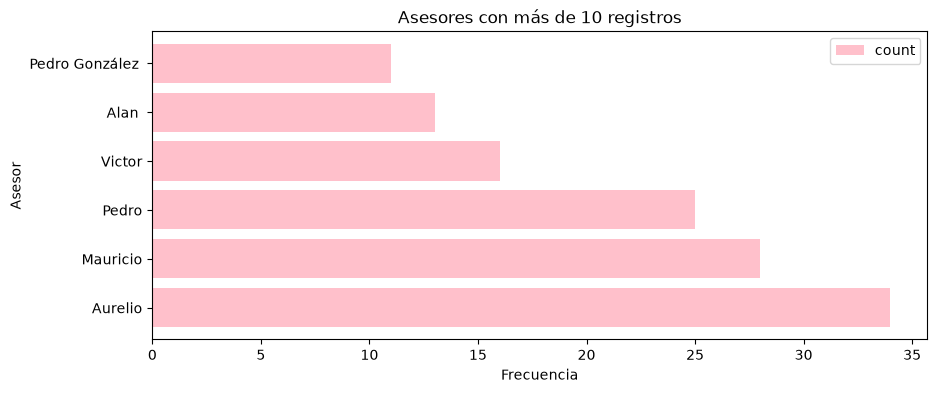

In [291]:
# Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'barh', width=0.8, figsize=(10,4), color= "pink")
plt.title('Asesores con más de 10 registros')
plt.xlabel('Frecuencia')
plt.ylabel('Asesor')

In [263]:
# Obtengo un análisis univariado de las variables categóricas - 2
Tabla_freq1 = bp['Nombre Cliente'].value_counts().reset_index()
Tabla_freq1

,Nombre Cliente,count
0,Sin datos,11
1,Victor Saavedra,2
2,Edmundo Carmelo Carballo,2
3,Jesus Olvera Sanchez,2
4,Daniel Suarez,2
...,...,...
188,Jose Luis Blaz,1
189,Erick Cruz,1
190,David Moran,1
191,Medeo Martínez Ferro,1


In [264]:
# Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro1 = Tabla_freq1[(Tabla_freq1['count'] >= 2) & (Tabla_freq1['Nombre Cliente'] != 'Sin datos')]
Filtro1

,Nombre Cliente,count
1,Victor Saavedra,2
2,Edmundo Carmelo Carballo,2
3,Jesus Olvera Sanchez,2
4,Daniel Suarez,2


In [265]:
# Ajusto el indice de mi dataframe
Filtro1_index= Filtro1.set_index('Nombre Cliente')
Filtro1_index

,count
Nombre Cliente,
Victor Saavedra,2
Edmundo Carmelo Carballo,2
Jesus Olvera Sanchez,2
Daniel Suarez,2


<Axes: xlabel='Nombre Cliente'>

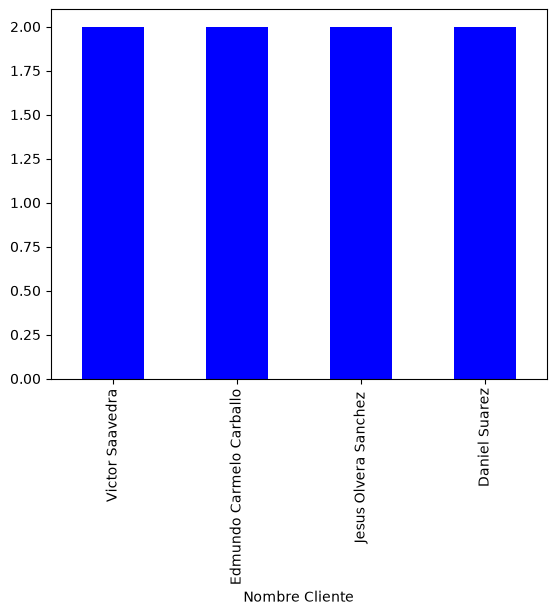

In [266]:
# Realizamos grafico de pastel del dataframe filtrado
Filtro1_index["count"].plot(kind='bar', color= "blue")

In [267]:
bp["Esatus Lead"].unique()


<StringArray>
[     'Activo',    'Cerrado ',      'Venta ',   'Sin datos',       'Venta',
     'Cerrado',  'Finalizado',     'Activo ', 'Finalizado ',       'venta']
Length: 10, dtype: str

In [268]:
# LIMPIAR NOMBRES COLUMNAS
bp["Esatus Lead"] = bp["Esatus Lead"].str.strip()
bp["Esatus Lead"] = bp["Esatus Lead"].str.title()

In [269]:
# Obtengo un análisis univariado de las variables categóricas - 2
Tabla_freq2 = bp['Esatus Lead'].value_counts().reset_index()
Tabla_freq2

,Esatus Lead,count
0,Activo,168
1,Cerrado,18
2,Sin Datos,11
3,Venta,6
4,Finalizado,4


In [270]:
# Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro2= Tabla_freq2[Tabla_freq2["Esatus Lead"] != "Sin Datos"]
Filtro2

,Esatus Lead,count
0,Activo,168
1,Cerrado,18
3,Venta,6
4,Finalizado,4


In [271]:
# Ajusto el indice de mi dataframe
Filtro2_index= Filtro2.set_index('Esatus Lead')
Filtro2_index

,count
Esatus Lead,
Activo,168
Cerrado,18
Venta,6
Finalizado,4


<Axes: title={'center': 'Estatus del Lead'}, xlabel='Estatus Lead'>

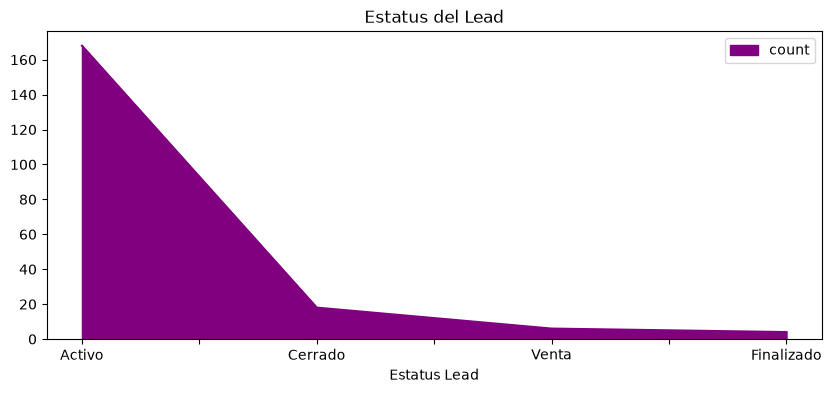

In [272]:
# Realizamos grafico de área del dataframe filtrado
Filtro2_index.plot(kind='area', figsize=(10,4),alpha = 1, color= "purple", title= "Estatus del Lead", xlabel= "Estatus Lead")

In [275]:
# Obtengo un análisis univariado de las variables categóricas - 2
Tabla_freq3 = bp['SDC'].value_counts().reset_index()
Tabla_freq3

,SDC,count
0,False,203
1,True,4


In [283]:
# Ajusto el indice de mi dataframe
Tabla_freq3= Tabla_freq3.set_index('SDC')
Tabla_freq3

,count
SDC,
False,203
True,4


<Axes: title={'center': 'Solicitud de Crédito'}>

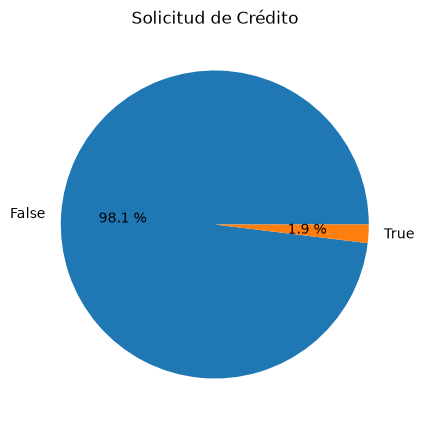

In [286]:
#Realizamos grafico de pastel del dataframe filtrado
Tabla_freq3["count"].plot(kind='pie', figsize=(10,5), autopct="%0.1f %%", title="Solicitud de Crédito")